# Импорт библиотек

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, RandomWalkWithDrift, AutoARIMA, AutoETS, AutoTheta

from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error

from mlforecast import MLForecast
from sklearn.svm import SVR
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor

from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS, LSTM, DLinear
from neuralforecast.losses.pytorch import RMSE

# Определение общих функций и переменных

In [2]:
# словарь содержащий все названия сохраненных таблиц
global_dict_files_table = {}

# словарь содержащий все лучшие модели на каждом этапе
global_dict_best_models = {}

#общее значение случайного состояния
RANDOM_STATE = 42

# сохранение результатов лучшей модели в глобальный словарь
def save_best_model_in_dict(model_name, data_predict):
    global_dict_best_models[model_name] = data_predict

# получение series из файла с данными
def get_data_from_file(file_name, name_val_col, name_date_col):
    local_df = pd.read_csv(file_name)
    local_df['dates'] = pd.to_datetime(local_df['date'])
    local_df['values'] = pd.to_numeric(local_df['values'])
    new_df = local_df[['dates', 'values']].copy()
    new_df = new_df.dropna(subset=['dates', 'values'])
    new_df = new_df.sort_values('dates')
    new_df = new_df.drop_duplicates(subset=['dates'], keep="last")
    series = pd.Series(new_df['values'].to_numpy(dtype=float), index=new_df['dates'], name=name_val_col)
    series.index.name = name_date_col
    return series

# получение statsforecast frame из series
def get_statsforecast_frame(series_name, data):
    return pd.DataFrame({"unique_id": series_name, "ds": data.index, "y": data.values})

# получение названий столбцов с результатми предсказаний
def get_data_columns_name(frame_pred):
    return frame_pred.columns.tolist()[2:]

# правильное разбиение временного ряда на тренировочную и тестовую выборки
def time_series_split(series_tmp):
    split_idx = int(len(series_tmp) * 0.85)
    train_series = series_tmp.iloc[:split_idx]
    test_series = series_tmp.iloc[split_idx:]
    return {
        'train_series_base': train_series,
        'test_series_base': test_series
    }

# получение разбияния выборки в формате tatsforecast frame
def get_statsforecast_frame_train_test(series_name, data):
    result_tmp = time_series_split(data)
    return {
        'train_statsforecast_frame': get_statsforecast_frame(series_name, result_tmp['train_series_base']),
        'test_statsforecast_frame': get_statsforecast_frame(series_name, result_tmp['test_series_base']),
    }

#получение метрик для полученных предсказаний
def calculate_metrics(y_pred, y_true):
    dct_metrics_tmp = {
        'MAPE': mean_absolute_percentage_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred)
    }
    return dct_metrics_tmp

# получение итоговой таблциы с метриками для одного вида моделей
def get_table_metric_by_models(test_df, calculated_df, model_names):
    local_test_data = test_df['y']
    local_calc_df = calculated_df[model_names]
    result_list_metric = []
    for model_tmp in model_names:
        result_metrics = {}
        metrics_calc = calculate_metrics(local_calc_df[model_tmp].values, local_test_data.values)
        result_metrics['MAPE'] = metrics_calc['MAPE']
        result_metrics['RMSE'] = metrics_calc['RMSE']
        result_metrics['Model'] = model_tmp
        result_list_metric.append(result_metrics)
    return pd.DataFrame(result_list_metric)

def save_csv_metrics(target_name, to_save_df, group_global_name):
    global_dict_files_table[group_global_name] = target_name
    to_save_df.to_csv(target_name, index=False)

#отображает разницу между исходным рядом и предсказанной частью
def draw_diff_pred_true(series_original, predict_part_dct, test_part, models_names):
    plt.figure(figsize=(16, 10))
    plt.plot(series_original.index, series_original.values, label='original series')
    for name_mdl in models_names:
        plt.plot(test_part, predict_part_dct[name_mdl], label=f'model: {name_mdl}')
    plt.legend()
    plt.title('Лучшие статистические методы')
    plt.xlabel('Год')
    plt.ylabel('Количество товаров')

# Задача 1

## Загрузка данных и EDA

### Базовое исследование данных

Для анализа временного ряда были взяты данные проданных товаров компании. Временной шаг между записями равен 1 месяцу, а сезонность равна 12.

In [3]:
series = get_data_from_file('sales_init.csv', 'values', 'dates')
series

dates
2005-01-01     462.0
2005-02-01     288.0
2005-03-01     219.0
2005-04-01     147.0
2005-05-01     108.0
               ...  
2011-01-01    1884.0
2011-02-01     924.0
2011-03-01     972.0
2011-04-01     744.0
2011-05-01     816.0
Name: values, Length: 77, dtype: float64

Посмотрим количество пропусков и статистику по целевому значению

In [4]:
series.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 77 entries, 2005-01-01 to 2011-05-01
Series name: values
Non-Null Count  Dtype  
--------------  -----  
77 non-null     float64
dtypes: float64(1)
memory usage: 1.2 KB


In [5]:
series.describe()

count      77.000000
mean      895.207792
std       595.291710
min       108.000000
25%       444.000000
50%       771.000000
75%      1176.000000
max      2685.000000
Name: values, dtype: float64

Пропусков в данных нет

### Визуализация данных и ее анализ

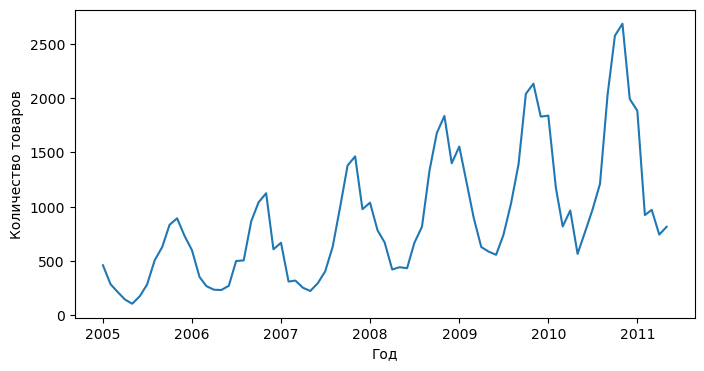

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(series.index, series.values)
plt.xlabel('Год')
plt.ylabel('Количество товаров')
plt.show()

Из графика виден возрастающий тренд, а также сильная сезонность. Также заметно, что разница минимального и максимального значений целевой перменной за сезон также растет с течением времени. Произведем разложение ряда на тренд, сезонную составляющую и шум.

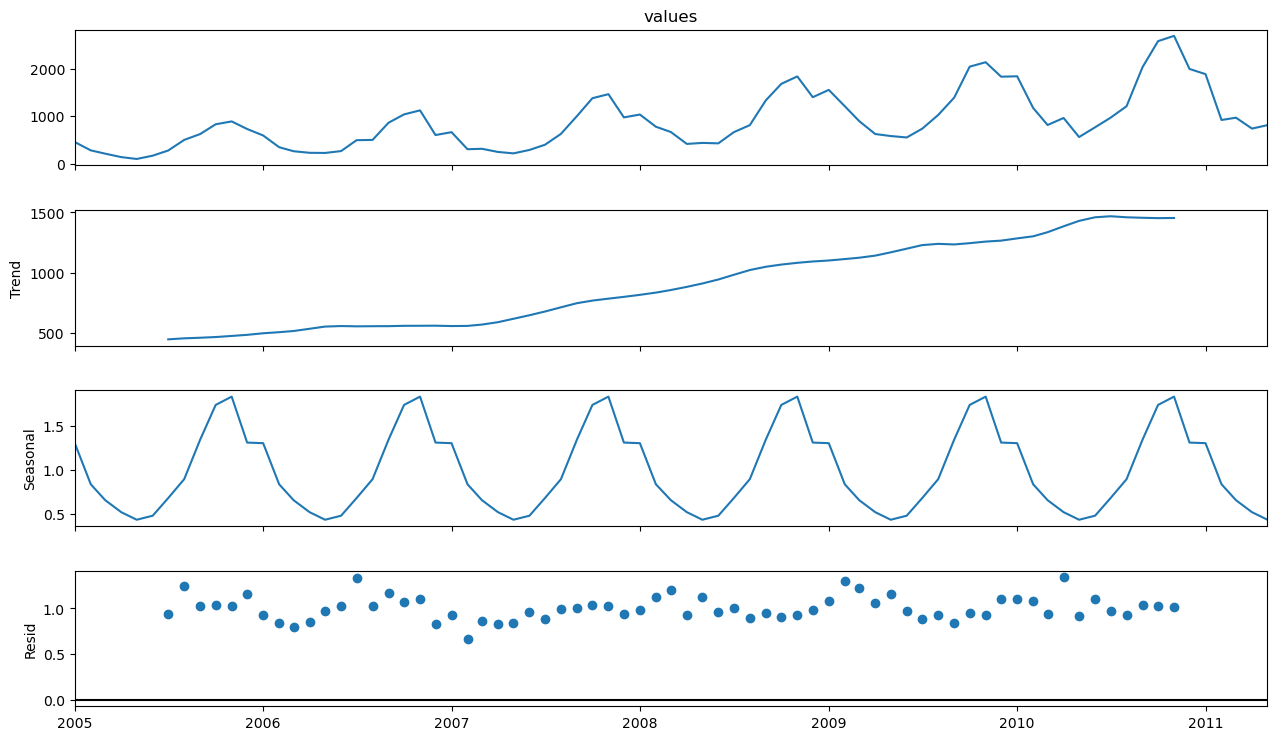

In [7]:
parts_of_time_series = seasonal_decompose(series, model='multiplicative', period=12)
fig = parts_of_time_series.plot()
fig.set_size_inches(14, 8)
plt.show()

Полученное разложение ряда подтверждает ранее сделанные выводы, а также из него видно, что шум обладает закономерностями в распределении значений. Также можно сказать, что ряд не является стационарным, однако применим критерий ADF, в котором за нулевую гипотезу принимается, что ряд не стационарен, и тогда при значении p_value большим 0.05 она принмается, если меньше то отвергается.

In [8]:
adf_result = adfuller(series, autolag='AIC')
p_value = adf_result[1]
print(p_value)

0.9888894205170051


Тест ADF подтвердил, что ряд не является стационарным.

# Задача 2

## Применение статистических моделей

### Получение метрик

Для применения моделей разобьем исходный ряд на тестовую и тренировочную части с помощью определенных в начале файла функций, которые учитывают необходимость правильного порядка разбиения, так как модель дожна предсказывать будущие значения ряда.

In [9]:
# Разбиение исходного ряда на train и test
dct_train_test = get_statsforecast_frame_train_test("products", series)
train = dct_train_test['train_statsforecast_frame']
test = dct_train_test['test_statsforecast_frame']

#определяем горизонт прогнозирования, возьмем 12 месяцев, так как для больших горизонтов могут возникать серьезные ошибки прогнозирования
length_test = len(test)

Определим 5 статистических моделей для прогнозирования. Naive в качестве базовой модели от качества которой будем расти. Так как в данных присутствует сезонность, имеет смысл также использовать SeasonalNaive в качетсве улучшенной базовой модели. Благодаря наличию учета тренда и сезонности в TS моделях, можно рассчитывать, что TS модели покажут себя хорошо, из них возьмем AutoETS и AutoTheta, чтобы получить автоподбор параметров. Также для сравнения возьмем AutoARIMA.

In [10]:
# Формируем список моделей
models = [
    Naive(),
    SeasonalNaive(season_length=12),
    AutoARIMA(season_length=12),
    AutoETS(season_length=12),
    AutoTheta(season_length=12),
]

# получаем предсказания
stats_forecast_obj = StatsForecast(models=models, freq="ME", n_jobs=-1)
stats_calc_df = stats_forecast_obj.forecast(df=train, h=length_test)
# полученные предсказания
stats_calc_df

,unique_id,ds,Naive,SeasonalNaive,AutoARIMA,AutoETS,AutoTheta
0,products,2010-05-31,567.0,558.0,695.814349,725.391484,709.962685
1,products,2010-06-30,567.0,741.0,808.164496,1097.141712,1049.151333
2,products,2010-07-31,567.0,1029.0,1127.593657,1499.091552,1409.169819
3,products,2010-08-31,567.0,1392.0,1476.612139,2104.293592,2094.393716
4,products,2010-09-30,567.0,2040.0,2130.831931,2701.729847,2749.340342
5,products,2010-10-31,567.0,2133.0,2221.065006,2761.739295,2938.694513
6,products,2010-11-30,567.0,1830.0,1919.295895,1983.142852,2074.854284
7,products,2010-12-31,567.0,1839.0,1927.748324,1943.229134,2089.976142
8,products,2011-01-31,567.0,1176.0,1264.991916,1251.106510,1363.566661
9,products,2011-02-28,567.0,819.0,907.883552,942.609808,1121.488242


Дальше будут применяться метрики MAPE (для хорошей интерпертируемости результата в процентах) и RMSE (для наличия дополнительного критерия оценки).

In [11]:
# получим и отобразим метрики для моделей
stats_metric = get_table_metric_by_models(test, stats_calc_df, get_data_columns_name(stats_calc_df))
save_csv_metrics('stats_models_metric_table.csv', stats_metric, "stats group models")
stats_metric

,MAPE,RMSE,Model
0,0.521941,1133.903766,Naive
1,0.210955,336.262175,SeasonalNaive
2,0.171872,289.898312,AutoARIMA
3,0.099992,151.581932,AutoETS
4,0.120713,187.001886,AutoTheta


### Анализ метрик

Из полученных метрик видно, что лучший результат по обоим метрикам пренадлежит AutoETS (MAPE=10% и RMSE=151) для исследуемого временного ряда. Модель AutoTheta показала близкий результат, проиграв на 2% по метрике MAPE и на 36 единиц по RMSE. На третьем месте находится модель AutoARIMA (MAPE=17% и RMSE=289), проигрывая лидеру больше, чем в 1.5 раза, чуть худшее качество демонстрирует SeasonalNaive (MAPE=21% и RMSE=336), проигрывая лидеру уже больше, чем в 2 раза. Naive показывает самый плохой результат, проигрывая лидеру в 5 раз. Поэтому с остальными результатами моделей других групп будет сравниваться результат AutoETS. Также сильная разница между Naive и SeasonalNaive - на 31% по MAPE и в 3 раза по RMSE, показывает, что учет сезонности повышает качество предсказаний для данного ряда.

In [12]:
# сохранение результатов лучшей статистической модели
stats_best_model_name = "AutoETS"
save_best_model_in_dict(stats_best_model_name, stats_calc_df[stats_best_model_name].values)

# Задача 3

## Применение ML-моделей

### Получение метрик

In [13]:
#определяем горизонт прогнозирования, возьмем 12 месяцев, так как для больших горизонтов могут возникать серьезные ошибки прогнозирования
length_test = len(test)

Для прогнозирования используем SVR с полиномиальным ядром, чтобы она лучше учитывала более сложные зависимости, а также ансамблевые методы RandomForestRegressor и AdaBoostRegressor для получения более точных результатов.

In [14]:
models = [SVR(kernel='poly'), RandomForestRegressor(n_estimators=100, max_depth=3, random_state=RANDOM_STATE), 
          AdaBoostRegressor(random_state=RANDOM_STATE, n_estimators=100),]

models_object = MLForecast(models=models, freq='MS', lags=[1, 2, 6, 12], date_features=['month'])

models_object.fit(train)
models_object_result_ML = models_object.predict(h=length_test)
models_object_result_ML

,unique_id,ds,SVR,RandomForestRegressor,AdaBoostRegressor
0,products,2010-06-01,635.400097,608.803094,658.625000
1,products,2010-07-01,639.412463,874.925299,749.086957
2,products,2010-08-01,709.675008,1353.326828,1320.000000
3,products,2010-09-01,783.688255,1802.659393,1757.250000
4,products,2010-10-01,994.078103,2020.208500,2040.000000
5,products,2010-11-01,1093.433711,2000.506000,2040.000000
6,products,2010-12-01,1084.097295,2029.543500,2040.000000
7,products,2011-01-01,1113.571440,2022.918500,2040.000000
8,products,2011-02-01,905.763176,1345.210877,1232.142857
9,products,2011-03-01,778.784509,1004.436030,909.000000


In [15]:
# получим и отобразим метрики для моделей
ML_metric = get_table_metric_by_models(test, models_object_result_ML, get_data_columns_name(models_object_result_ML))
save_csv_metrics('ML_models_metric_table.csv', ML_metric, "ML group models")
ML_metric

,MAPE,RMSE,Model
0,0.335294,838.742448,SVR
1,0.215992,348.003693,RandomForestRegressor
2,0.191496,313.649545,AdaBoostRegressor


### Анализ метрик

Из полученных метрик видно, что лучшей по обоим метрикам является AdaBoostRegressor (MAPE=19% и RMSE=313). Близкой по качеству, но немного проигрывающей, оказывается RandomForestRegressor, проигрывая 2.5% по MAPE. Самой плохой оказалась модель SVR (MAPE=33% и RMSE=838), проигрывая на 14% по MAPE лидеру, и оказываясь больше лидера по RMSE в два раза.Таким образом лучшей моделью в данной группе оказывается AdaBoostRegressor.

In [16]:
# сохранение результатов лучшей ML модели
ML_best_model_name = "AdaBoostRegressor"
save_best_model_in_dict(ML_best_model_name, models_object_result_ML[ML_best_model_name].values)

## Применение DL-моделей

### Получение метрик

Для прогнозирования временных рядов используем модели: NHITS, LSTM и DLinear.

In [17]:
LOCAL_MAX_STEPS_CONST = 100
LOCAL_INPUT_SIZE_CONST = length_test * 3
models = [
    DLinear(h=length_test, input_size=LOCAL_INPUT_SIZE_CONST, loss=RMSE(), 
            max_steps=LOCAL_MAX_STEPS_CONST, random_seed=RANDOM_STATE, enable_progress_bar=False),
    NHITS(h=length_test, input_size=LOCAL_INPUT_SIZE_CONST, loss=RMSE(), 
          max_steps=LOCAL_MAX_STEPS_CONST, random_seed=RANDOM_STATE, enable_progress_bar=False),
    LSTM(h=length_test, input_size=LOCAL_INPUT_SIZE_CONST, loss=RMSE(), 
         max_steps=LOCAL_MAX_STEPS_CONST, random_seed=RANDOM_STATE, enable_progress_bar=False),
]

neural_forecast_obj = NeuralForecast(models=models, freq='MS')
neural_forecast_obj.fit(df=train)
neural_forecast_obj_pred = neural_forecast_obj.predict()
neural_forecast_obj_pred

Seed set to 42
Seed set to 42
Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | loss          | RMSE          | 0      | train
1 | padder_train  | ConstantPad1d | 0      | train
2 | scaler        | TemporalNorm  | 0      | train
3 | decomp        | SeriesDecomp  | 0      | train
4 | linear_trend  | Linear        | 444    | train
5 | linear_season | Linear        | 444    | train
--------------------------------------------------------
888       Trainable params
0         Non-trainable params
888       Total params
0.004     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode
/home/nebuarcnew/anaconda3/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

,unique_id,ds,DLinear,NHITS,LSTM
0,products,2010-06-01,514.268494,510.686035,884.712830
1,products,2010-07-01,115.999268,720.698547,990.775330
2,products,2010-08-01,-117.097565,1001.242920,1256.006470
3,products,2010-09-01,-1128.110352,1418.630127,1734.971924
4,products,2010-10-01,88.524155,2183.300293,2432.484863
5,products,2010-11-01,754.913940,2467.999756,2771.073242
6,products,2010-12-01,-482.484650,2125.582031,2581.034912
7,products,2011-01-01,215.063126,2089.348633,2298.474121
8,products,2011-02-01,221.752548,1567.387207,1859.232178
9,products,2011-03-01,-803.973633,1047.893555,1405.109253


In [18]:
# получим и отобразим метрики для моделей
DL_metric = get_table_metric_by_models(test, neural_forecast_obj_pred, get_data_columns_name(neural_forecast_obj_pred))
save_csv_metrics('DL_models_metric_table.csv', DL_metric, "DL group models")
DL_metric

,MAPE,RMSE,Model
0,1.024770,1740.924543,DLinear
1,0.233845,331.960628,NHITS
2,0.256269,395.486737,LSTM


### Анализ метрик

DLinear показала самый худший резльтат в данной группе моделей а также среди вообще всех моделей (MAPE=102% RMSE=1740). NHITS (MAPE=23% RMSE=331) и LSTM (MAPE=25% RMSE=395) показывают похожие результаты, но NHITS лучше на 2% по MAPE и на 64 единицы по RMSE. Таким образом, в данной группе лучшей моделью выбрана NHITS.

In [19]:
# сохранение результатов лучшей ML модели
DL_best_model_name = "NHITS"
save_best_model_in_dict(DL_best_model_name, neural_forecast_obj_pred[DL_best_model_name].values)

## Сравнение лучших моделей из каждой группы для прогнозирования

На данный момент получено 3 лучших модели, по одной из каждой группы: AutoETS (MAPE=10% и RMSE=151), AdaBoostRegressor (MAPE=19% и RMSE=313) и NHITS (MAPE=23% и RMSE=331). Из представленных результатов видно, что AutoETS является лучшей моделью для прогнозирования значений данного ряда, хуже ее на 9% по MAPE и в 2 раза по RMSE является AdaBoostRegressor, а хуже модели AdaBoostRegressor на 4% по MAPE и немного по RMSE является модель NHITS.

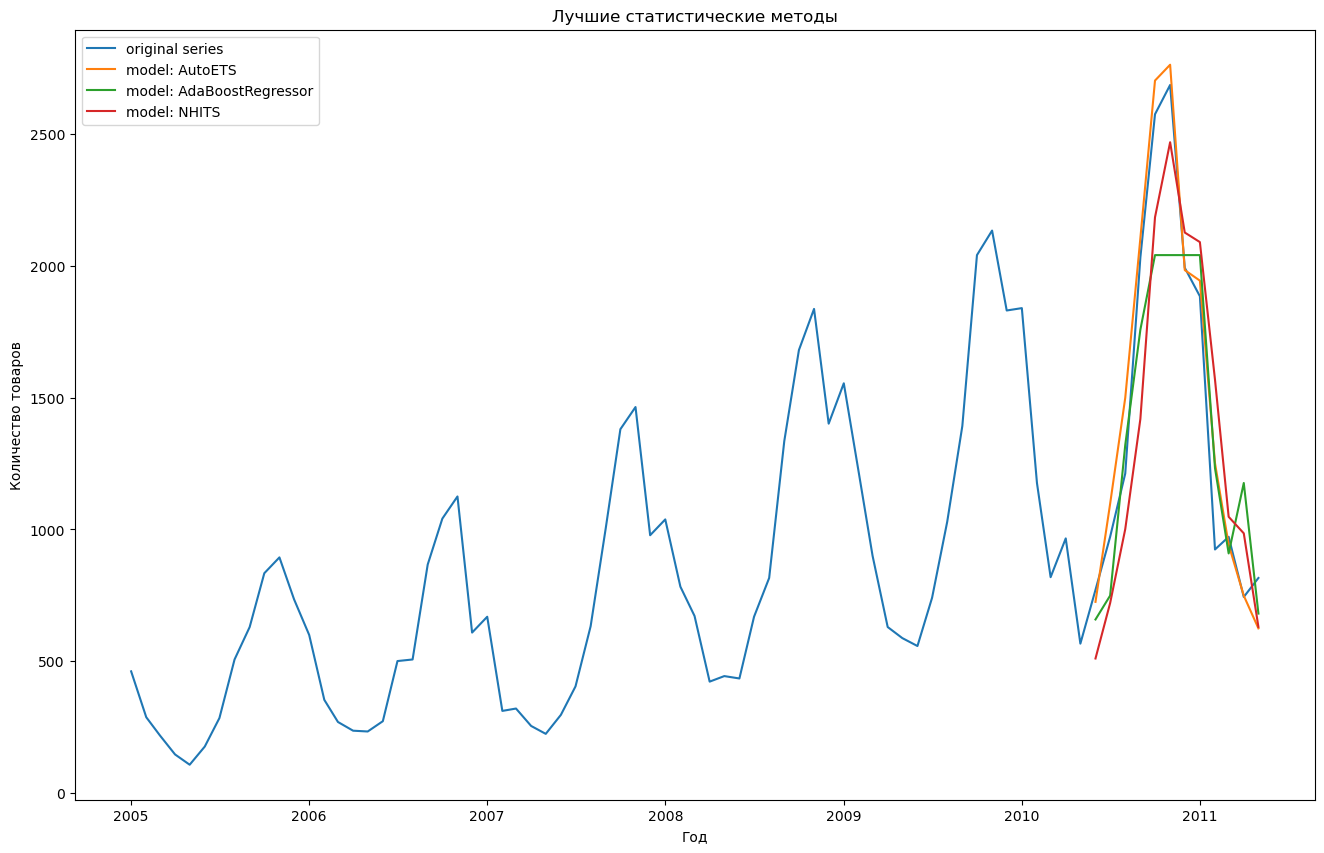

In [20]:
# построим общий график сравнения прогнозирования значений моделями с реальным рядом
draw_diff_pred_true(series, global_dict_best_models, test['ds'], ['AutoETS', 'AdaBoostRegressor', 'NHITS'])

Из графиков также следует превосходство AutoETS над другими двумя моделями.

# Задача 4

## Определим функцию для запуска пайплайна и запустим пайплайн

In [21]:
#Функция запуска работы пайплайна
def run_pipeline(data_series, group_models, name_ts="ts_data"):
    #начало отсчета времени работы пайплайна
    start_work_pipeline = time.time()
    
    # разбиение исходного ряда на train и test
    dct_train_test_local = get_statsforecast_frame_train_test(name_ts, data_series)
    train_local = dct_train_test_local['train_statsforecast_frame']
    test_local = dct_train_test_local['test_statsforecast_frame']
    
    #определяем горизонт прогнозирования, как длину тестовой выборки
    length_test_local = len(test_local)
    
    #получение результатов работы группы алгоритмов
    result_pipe_local = group_models.forecast(df=train_local, h=length_test_local)
    
    #получение метрик алгоритмов
    metric_local = get_table_metric_by_models(test_local, result_pipe_local, get_data_columns_name(result_pipe_local))
    
    # сохранение метрик
    show_metric = get_table_metric_by_models(test_local, result_pipe_local, get_data_columns_name(result_pipe_local))
    
    
    #измерение и отображение времени работы пайплайна
    end_work_pipeline = time.time()
    execution_time_work_pipeline = end_work_pipeline - start_work_pipeline
    print(f"Время выполнения: {execution_time_work_pipeline} секунд")

    return {
        'metrics': show_metric
    }
    
    

После определния функции пайплайна запустим ее для наилучшей выбранной модели, чтобы спрогнозировать значения временного ряда. А также добавим две базовых модели для сравнения.

In [22]:
series = get_data_from_file('sales_init.csv', 'values', 'dates')
metrics_pipe = run_pipeline(series, StatsForecast(models=[Naive(), 
                                                          SeasonalNaive(season_length=12), 
                                                          AutoETS(season_length=12)], freq="ME", n_jobs=-1))

Время выполнения: 0.09789633750915527 секунд


In [23]:
metrics_pipe['metrics']

,MAPE,RMSE,Model
0,0.521941,1133.903766,Naive
1,0.210955,336.262175,SeasonalNaive
2,0.099992,151.581932,AutoETS


Построенный пайплайн отработал корректно, предоставив время работы и метрики моделей.

# Итоги

При анализе исследуемого ряда были выявлены его характеристики: выраженная сезонность, восходящий тренд, временной шаг в месяц и отсутствие стационарности, а пропуски в данных отсутствовали. После анализа представленного ряда и его обработки в ходе данной работы были применены различные методы прогнозирования временных рядов. Показанные результаты сравнивались по метрикам качества. Лучше всего для прогнозирования исследуемого ряда подходили методы статистической группы, среди которых лучшим оказался - AutoETS с метриками MAPE=10% и RMSE=151. После чего был сформирован пайплайн моделей и запущен. Пайплайн корректно отработал и продемонстрировал те же метрики для моделей, которые были отображены при анализе.